In [ ]:
import warnings
warnings.filterwarnings ('ignore')

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn import linear_model
from sklearn.linear_model import LogisticRegression
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn import preprocessing

In [ ]:
# Read the csv file using 'read_csv'. Please write your dataset location here.

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Lead Scoring Assignment - Logistic Regression/Leads.csv')
df.head()

,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,...,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737,API,Olark Chat,No,No,0,0.0,0,0.0,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Modified
1,2a272436-5132-4136-86fa-dcc88c88f482,660728,API,Organic Search,No,No,0,5.0,674,2.5,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Email Opened
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,660727,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,2.0,...,No,Potential Lead,Mumbai,02.Medium,01.High,14.0,20.0,No,Yes,Email Opened
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,660719,Landing Page Submission,Direct Traffic,No,No,0,1.0,305,1.0,...,No,Select,Mumbai,02.Medium,01.High,13.0,17.0,No,No,Modified
4,3256f628-e534-4826-9d63-4a8b88782852,660681,Landing Page Submission,Google,No,No,1,2.0,1428,1.0,...,No,Select,Mumbai,02.Medium,01.High,15.0,18.0,No,No,Modified


In [ ]:
df.shape

(9240, 37)

In [ ]:
### EDA

df.describe()

,Lead Number,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Asymmetrique Activity Score,Asymmetrique Profile Score
count,9240.000000,9240.000000,9103.000000,9240.000000,9103.000000,5022.000000,5022.000000
mean,617188.435606,0.385390,3.445238,487.698268,2.362820,14.306252,16.344883
std,23405.995698,0.486714,4.854853,548.021466,2.161418,1.386694,1.811395
min,579533.000000,0.000000,0.000000,0.000000,0.000000,7.000000,11.000000
25%,596484.500000,0.000000,1.000000,12.000000,1.000000,14.000000,15.000000
50%,615479.000000,0.000000,3.000000,248.000000,2.000000,14.000000,16.000000
75%,637387.250000,1.000000,5.000000,936.000000,3.000000,15.000000,18.000000
max,660737.000000,1.000000,251.000000,2272.000000,55.000000,18.000000,20.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 37 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Prospect ID                                    9240 non-null   object 
 1   Lead Number                                    9240 non-null   int64  
 2   Lead Origin                                    9240 non-null   object 
 3   Lead Source                                    9204 non-null   object 
 4   Do Not Email                                   9240 non-null   object 
 5   Do Not Call                                    9240 non-null   object 
 6   Converted                                      9240 non-null   int64  
 7   TotalVisits                                    9103 non-null   float64
 8   Total Time Spent on Website                    9240 non-null   int64  
 9   Page Views Per Visit                           9103 

In [ ]:
null = df.isnull().sum()/len(df)*100
null

,0
Prospect ID,0.000000
Lead Number,0.000000
Lead Origin,0.000000
Lead Source,0.389610
Do Not Email,0.000000
Do Not Call,0.000000
Converted,0.000000
TotalVisits,1.482684
Total Time Spent on Website,0.000000
Page Views Per Visit,1.482684


In [ ]:
too_much_nulls = null[null.values >25]
too_much_nulls

,0
Country,26.634199
What is your current occupation,29.112554
What matters most to you in choosing a course,29.318182
Tags,36.287879
Lead Quality,51.590909
Lead Profile,29.318182
Asymmetrique Activity Index,45.649351
Asymmetrique Profile Index,45.649351
Asymmetrique Activity Score,45.649351
Asymmetrique Profile Score,45.649351


In [ ]:
l = list(too_much_nulls.index)
df.drop(labels = l, axis =1, inplace = True)
df.shape

(9240, 27)

In [ ]:
df['How did you hear about X Education'].value_counts()

,count
How did you hear about X Education,
Select,5043
Online Search,808
Word Of Mouth,348
Student of SomeSchool,310
Other,186
Multiple Sources,152
Advertisements,70
Social Media,67
Email,26


In [ ]:
df.drop('How did you hear about X Education', axis =1, inplace = True )

In [ ]:
df.isnull().sum()/len(df)*100

,0
Prospect ID,0.000000
Lead Number,0.000000
Lead Origin,0.000000
Lead Source,0.389610
Do Not Email,0.000000
Do Not Call,0.000000
Converted,0.000000
TotalVisits,1.482684
Total Time Spent on Website,0.000000
Page Views Per Visit,1.482684


In [ ]:
df['City'].value_counts()

,count
City,
Mumbai,3222
Select,2249
Thane & Outskirts,752
Other Cities,686
Other Cities of Maharashtra,457
Other Metro Cities,380
Tier II Cities,74


In [ ]:
df['Specialization'].value_counts()

,count
Specialization,
Select,1942
Finance Management,976
Human Resource Management,848
Marketing Management,838
Operations Management,503
Business Administration,403
IT Projects Management,366
Supply Chain Management,349
"Banking, Investment And Insurance",338


In [ ]:
df.drop(['City','Specialization'], axis =1 , inplace = True)

In [ ]:
df.isnull().sum()/len(df)*100

,0
Prospect ID,0.000000
Lead Number,0.000000
Lead Origin,0.000000
Lead Source,0.389610
Do Not Email,0.000000
Do Not Call,0.000000
Converted,0.000000
TotalVisits,1.482684
Total Time Spent on Website,0.000000
Page Views Per Visit,1.482684


In [ ]:
df.drop('Prospect ID',axis = 1, inplace = True)

In [ ]:
df.drop('Lead Number', axis =1, inplace = True)

In [ ]:
df.head()

,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,Search,...,X Education Forums,Newspaper,Digital Advertisement,Through Recommendations,Receive More Updates About Our Courses,Update me on Supply Chain Content,Get updates on DM Content,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
0,API,Olark Chat,No,No,0,0.0,0,0.0,Page Visited on Website,No,...,No,No,No,No,No,No,No,No,No,Modified
1,API,Organic Search,No,No,0,5.0,674,2.5,Email Opened,No,...,No,No,No,No,No,No,No,No,No,Email Opened
2,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,2.0,Email Opened,No,...,No,No,No,No,No,No,No,No,Yes,Email Opened
3,Landing Page Submission,Direct Traffic,No,No,0,1.0,305,1.0,Unreachable,No,...,No,No,No,No,No,No,No,No,No,Modified
4,Landing Page Submission,Google,No,No,1,2.0,1428,1.0,Converted to Lead,No,...,No,No,No,No,No,No,No,No,No,Modified


In [ ]:
df['Lead Origin'].value_counts()

,count
Lead Origin,
Landing Page Submission,4886
API,3580
Lead Add Form,718
Lead Import,55
Quick Add Form,1


In [ ]:
df.columns

Index(['Lead Origin', 'Lead Source', 'Do Not Email', 'Do Not Call',
       'Converted', 'TotalVisits', 'Total Time Spent on Website',
       'Page Views Per Visit', 'Last Activity', 'Search', 'Magazine',
       'Newspaper Article', 'X Education Forums', 'Newspaper',
       'Digital Advertisement', 'Through Recommendations',
       'Receive More Updates About Our Courses',
       'Update me on Supply Chain Content', 'Get updates on DM Content',
       'I agree to pay the amount through cheque',
       'A free copy of Mastering The Interview', 'Last Notable Activity'],
      dtype='object')

In [ ]:
df['Last Notable Activity'].value_counts()

,count
Last Notable Activity,
Modified,3407
Email Opened,2827
SMS Sent,2172
Page Visited on Website,318
Olark Chat Conversation,183
Email Link Clicked,173
Email Bounced,60
Unsubscribed,47
Unreachable,32


In [ ]:
l =['Do Not Call','Search', 'Magazine',
       'Newspaper Article', 'X Education Forums', 'Newspaper', 'Digital Advertisement', 'Through Recommendations',
       'Receive More Updates About Our Courses',
       'Update me on Supply Chain Content', 'Get updates on DM Content',
       'I agree to pay the amount through cheque']

In [ ]:
df.drop(labels = l, axis = 1, inplace = True)

In [ ]:
df.head()

,Lead Origin,Lead Source,Do Not Email,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,A free copy of Mastering The Interview,Last Notable Activity
0,API,Olark Chat,No,0,0.0,0,0.0,Page Visited on Website,No,Modified
1,API,Organic Search,No,0,5.0,674,2.5,Email Opened,No,Email Opened
2,Landing Page Submission,Direct Traffic,No,1,2.0,1532,2.0,Email Opened,Yes,Email Opened
3,Landing Page Submission,Direct Traffic,No,0,1.0,305,1.0,Unreachable,No,Modified
4,Landing Page Submission,Google,No,1,2.0,1428,1.0,Converted to Lead,No,Modified


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 10 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Lead Origin                             9240 non-null   object 
 1   Lead Source                             9204 non-null   object 
 2   Do Not Email                            9240 non-null   object 
 3   Converted                               9240 non-null   int64  
 4   TotalVisits                             9103 non-null   float64
 5   Total Time Spent on Website             9240 non-null   int64  
 6   Page Views Per Visit                    9103 non-null   float64
 7   Last Activity                           9137 non-null   object 
 8   A free copy of Mastering The Interview  9240 non-null   object 
 9   Last Notable Activity                   9240 non-null   object 
dtypes: float64(2), int64(2), object(6)
memory usage: 722.0+ KB


In [ ]:
top = 7
top_category = df['Lead Source'].value_counts().nlargest(top).index

top_category

Index(['Google', 'Direct Traffic', 'Olark Chat', 'Organic Search', 'Reference',
       'Welingak Website', 'Referral Sites'],
      dtype='object', name='Lead Source')

In [ ]:
df['Lead Source'] = df['Lead Source'].where(
    df['Lead Source'].isin(top_category),"Other"
)

In [ ]:
df['Lead Source'].value_counts()

,count
Lead Source,
Google,2868
Direct Traffic,2543
Olark Chat,1755
Organic Search,1154
Reference,534
Welingak Website,142
Referral Sites,125
Other,119


In [ ]:
df['Last Notable Activity'].value_counts()

,count
Last Notable Activity,
Modified,3407
Email Opened,2827
SMS Sent,2172
Page Visited on Website,318
Olark Chat Conversation,183
Email Link Clicked,173
Email Bounced,60
Unsubscribed,47
Unreachable,32


In [ ]:
top = 7
top_category = df['Last Activity'].value_counts().nlargest(top).index

df['Last Activity'] = df['Last Activity'].where(
    df['Last Activity'].isin(top_category),"Other"
)

df['Last Activity'].value_counts()

,count
Last Activity,
Email Opened,3437
SMS Sent,2745
Olark Chat Conversation,973
Page Visited on Website,640
Converted to Lead,428
Other,424
Email Bounced,326
Email Link Clicked,267


In [ ]:
top = 7
top_category = df['Last Notable Activity'].value_counts().nlargest(top).index

df['Last Notable Activity'] = df['Last Notable Activity'].where(
    df['Last Notable Activity'].isin(top_category),"Other"
)

df['Last Notable Activity'].value_counts()

,count
Last Notable Activity,
Modified,3407
Email Opened,2827
SMS Sent,2172
Page Visited on Website,318
Olark Chat Conversation,183
Email Link Clicked,173
Other,100
Email Bounced,60


In [ ]:
df.head()

,Lead Origin,Lead Source,Do Not Email,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,A free copy of Mastering The Interview,Last Notable Activity
0,API,Olark Chat,No,0,0.0,0,0.0,Page Visited on Website,No,Modified
1,API,Organic Search,No,0,5.0,674,2.5,Email Opened,No,Email Opened
2,Landing Page Submission,Direct Traffic,No,1,2.0,1532,2.0,Email Opened,Yes,Email Opened
3,Landing Page Submission,Direct Traffic,No,0,1.0,305,1.0,Other,No,Modified
4,Landing Page Submission,Google,No,1,2.0,1428,1.0,Converted to Lead,No,Modified


In [ ]:
binary = ['Do Not Email','A free copy of Mastering The Interview']
def binary_map(x):
  return x.map({'Yes':1,'No':0})

df[binary] = df[binary].apply(binary_map)
df[binary].head()


,Do Not Email,A free copy of Mastering The Interview
0,0,0
1,0,0
2,0,1
3,0,0
4,0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 10 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Lead Origin                             9240 non-null   object 
 1   Lead Source                             9240 non-null   object 
 2   Do Not Email                            9240 non-null   int64  
 3   Converted                               9240 non-null   int64  
 4   TotalVisits                             9103 non-null   float64
 5   Total Time Spent on Website             9240 non-null   int64  
 6   Page Views Per Visit                    9103 non-null   float64
 7   Last Activity                           9240 non-null   object 
 8   A free copy of Mastering The Interview  9240 non-null   int64  
 9   Last Notable Activity                   9240 non-null   object 
dtypes: float64(2), int64(4), object(4)
memory usage: 722.0+ KB


In [ ]:
cat = ['Lead Origin','Lead Source','Last Activity','Last Notable Activity']
###3 One Hot Encoding

dummy = pd.get_dummies(df[cat],drop_first = True)
df = pd.concat([df,dummy], axis = 1 )
df.head()

,Lead Origin,Lead Source,Do Not Email,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,A free copy of Mastering The Interview,Last Notable Activity,...,Last Activity_Other,Last Activity_Page Visited on Website,Last Activity_SMS Sent,Last Notable Activity_Email Link Clicked,Last Notable Activity_Email Opened,Last Notable Activity_Modified,Last Notable Activity_Olark Chat Conversation,Last Notable Activity_Other,Last Notable Activity_Page Visited on Website,Last Notable Activity_SMS Sent
0,API,Olark Chat,0,0,0.0,0,0.0,Page Visited on Website,0,Modified,...,False,True,False,False,False,True,False,False,False,False
1,API,Organic Search,0,0,5.0,674,2.5,Email Opened,0,Email Opened,...,False,False,False,False,True,False,False,False,False,False
2,Landing Page Submission,Direct Traffic,0,1,2.0,1532,2.0,Email Opened,1,Email Opened,...,False,False,False,False,True,False,False,False,False,False
3,Landing Page Submission,Direct Traffic,0,0,1.0,305,1.0,Other,0,Modified,...,True,False,False,False,False,True,False,False,False,False
4,Landing Page Submission,Google,0,1,2.0,1428,1.0,Converted to Lead,0,Modified,...,False,False,False,False,False,True,False,False,False,False


In [ ]:
df.shape

(9240, 35)

In [ ]:
df.drop(cat, axis = 1, inplace = True)
df.shape

(9240, 31)

<Axes: >

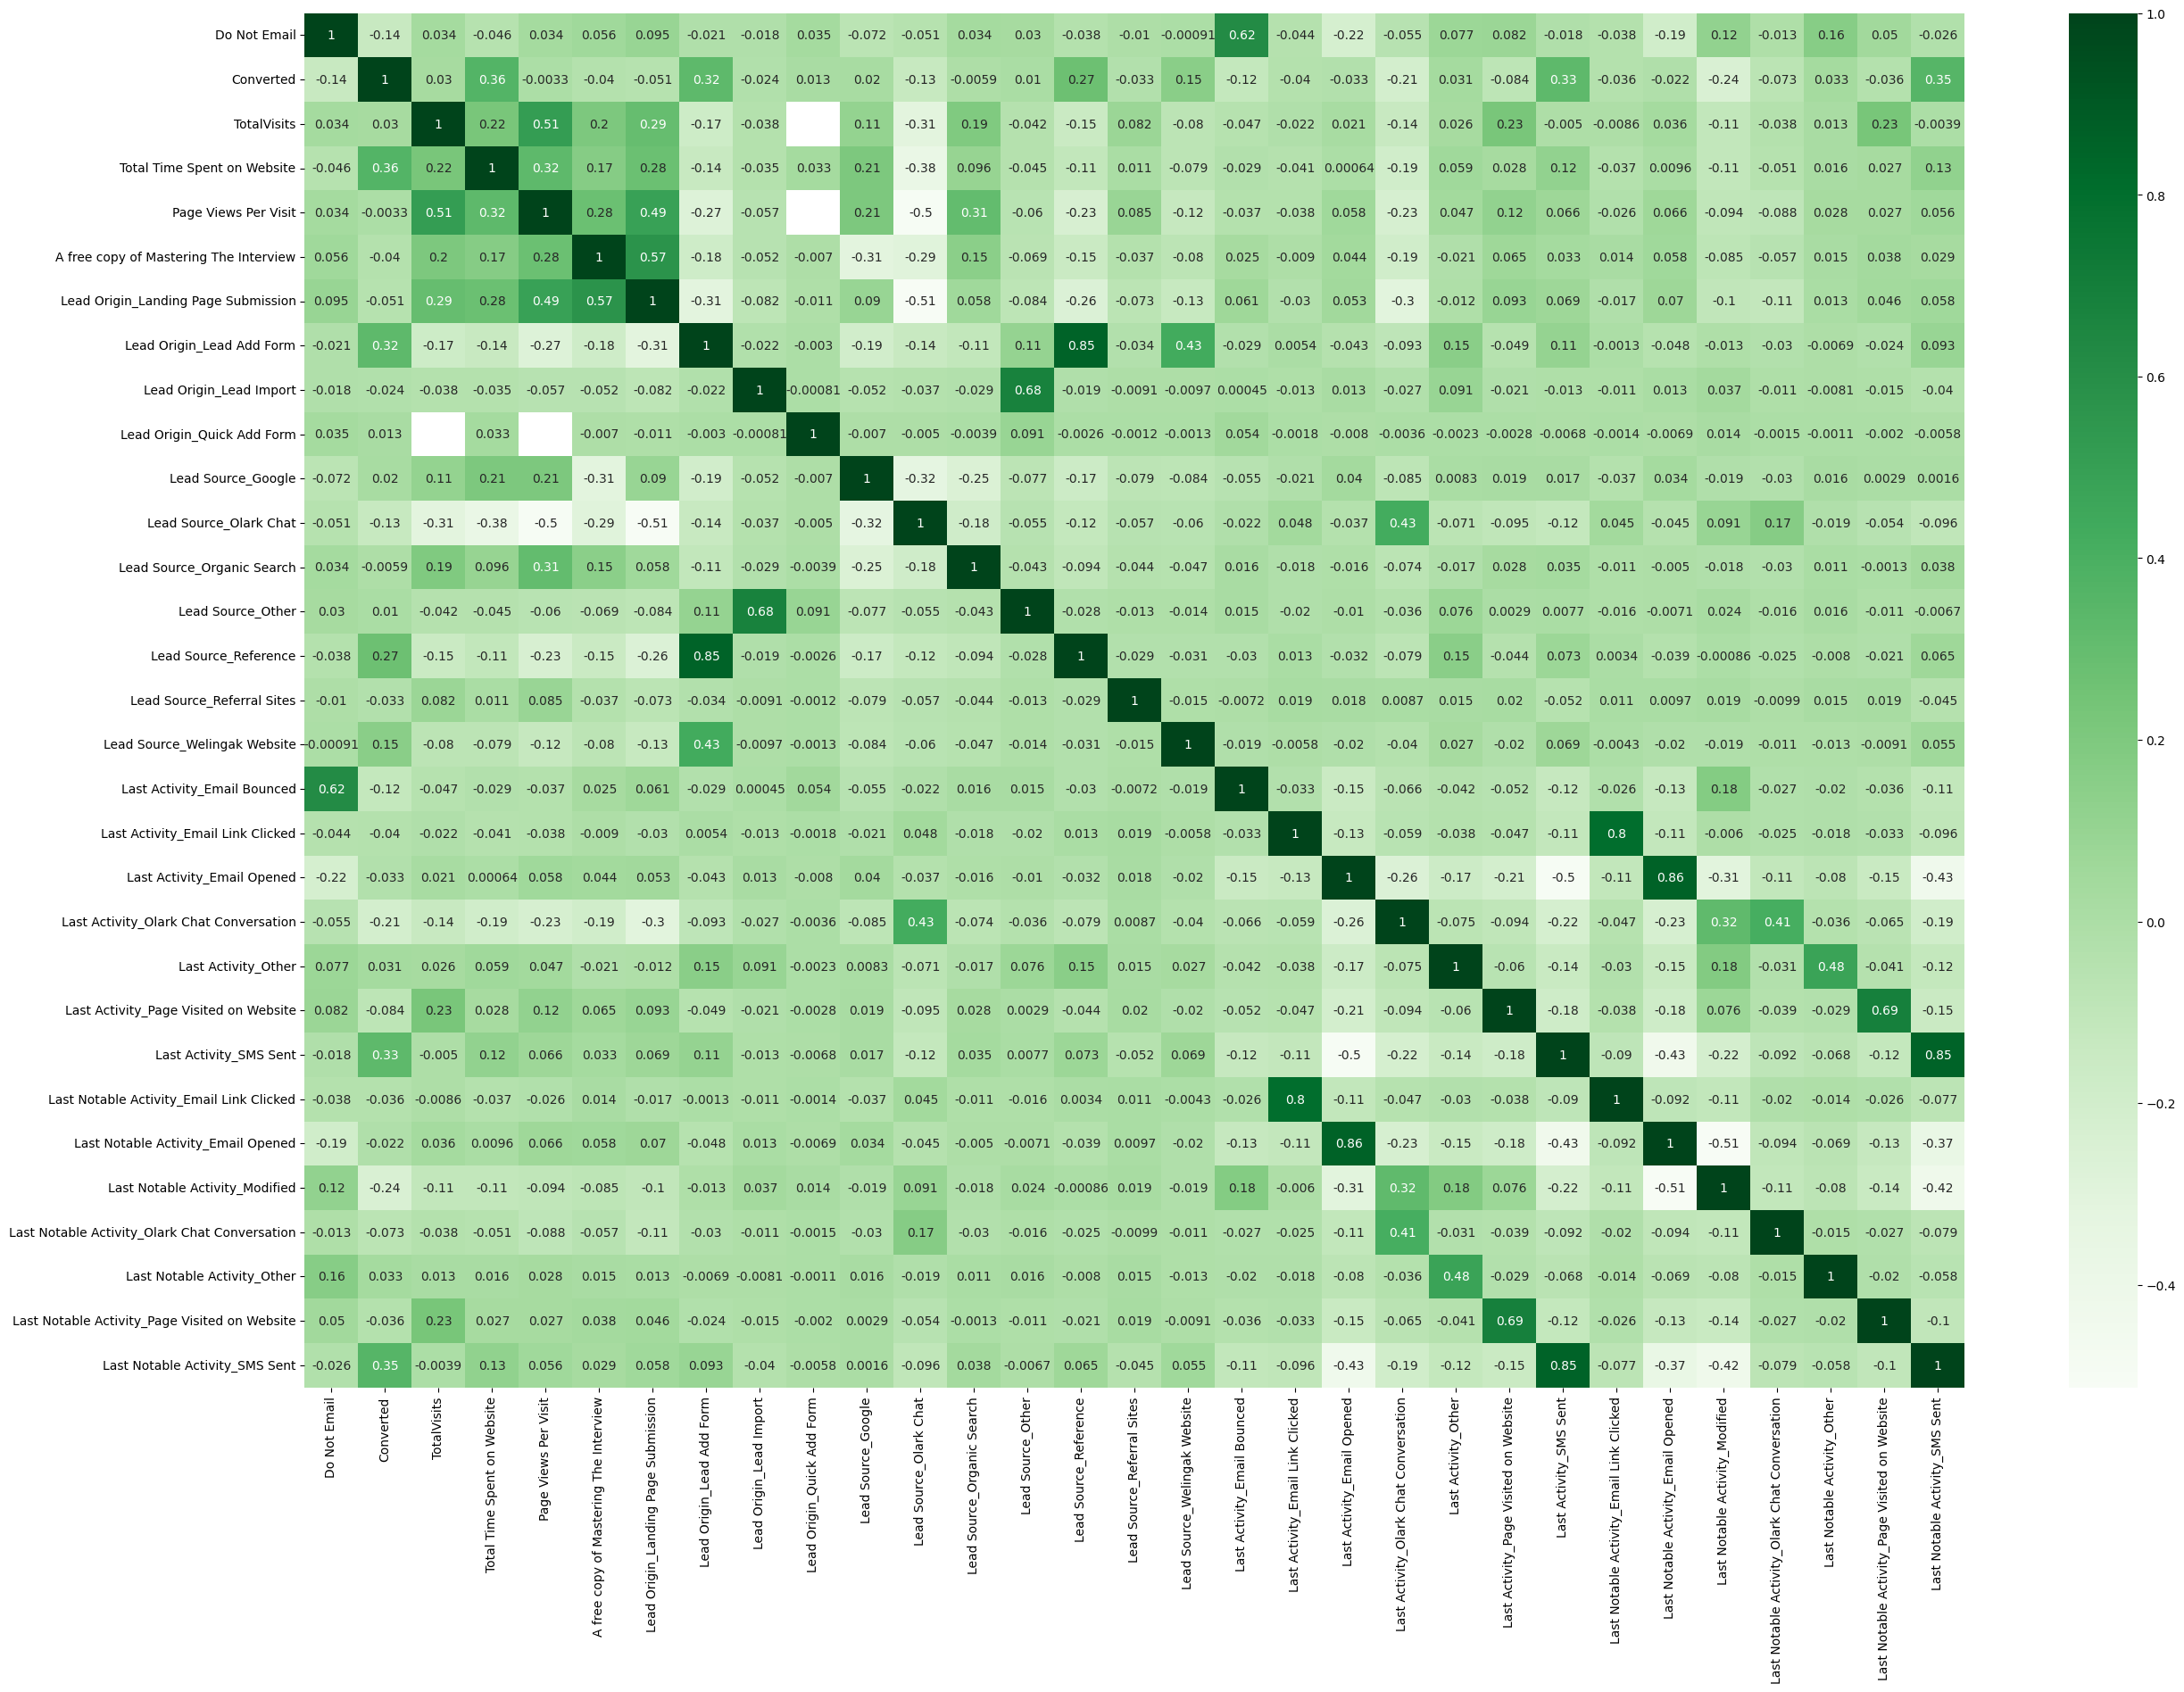

In [ ]:
plt.figure (figsize = (30,20))
sns.heatmap(df.corr(), annot = True, cmap = 'Greens')

In [ ]:
df.head()

,Do Not Email,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,A free copy of Mastering The Interview,Lead Origin_Landing Page Submission,Lead Origin_Lead Add Form,Lead Origin_Lead Import,Lead Origin_Quick Add Form,...,Last Activity_Other,Last Activity_Page Visited on Website,Last Activity_SMS Sent,Last Notable Activity_Email Link Clicked,Last Notable Activity_Email Opened,Last Notable Activity_Modified,Last Notable Activity_Olark Chat Conversation,Last Notable Activity_Other,Last Notable Activity_Page Visited on Website,Last Notable Activity_SMS Sent
0,0,0,0.0,0,0.0,0,False,False,False,False,...,False,True,False,False,False,True,False,False,False,False
1,0,0,5.0,674,2.5,0,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
2,0,1,2.0,1532,2.0,1,True,False,False,False,...,False,False,False,False,True,False,False,False,False,False
3,0,0,1.0,305,1.0,0,True,False,False,False,...,True,False,False,False,False,True,False,False,False,False
4,0,1,2.0,1428,1.0,0,True,False,False,False,...,False,False,False,False,False,True,False,False,False,False


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 31 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Do Not Email                                   9240 non-null   int64  
 1   Converted                                      9240 non-null   int64  
 2   TotalVisits                                    9103 non-null   float64
 3   Total Time Spent on Website                    9240 non-null   int64  
 4   Page Views Per Visit                           9103 non-null   float64
 5   A free copy of Mastering The Interview         9240 non-null   int64  
 6   Lead Origin_Landing Page Submission            9240 non-null   bool   
 7   Lead Origin_Lead Add Form                      9240 non-null   bool   
 8   Lead Origin_Lead Import                        9240 non-null   bool   
 9   Lead Origin_Quick Add Form                     9240 

In [ ]:
bool_col = df.columns[df.dtypes == 'bool'].tolist()
bool_col

['Lead Origin_Landing Page Submission',
 'Lead Origin_Lead Add Form',
 'Lead Origin_Lead Import',
 'Lead Origin_Quick Add Form',
 'Lead Source_Google',
 'Lead Source_Olark Chat',
 'Lead Source_Organic Search',
 'Lead Source_Other',
 'Lead Source_Reference',
 'Lead Source_Referral Sites',
 'Lead Source_Welingak Website',
 'Last Activity_Email Bounced',
 'Last Activity_Email Link Clicked',
 'Last Activity_Email Opened',
 'Last Activity_Olark Chat Conversation',
 'Last Activity_Other',
 'Last Activity_Page Visited on Website',
 'Last Activity_SMS Sent',
 'Last Notable Activity_Email Link Clicked',
 'Last Notable Activity_Email Opened',
 'Last Notable Activity_Modified',
 'Last Notable Activity_Olark Chat Conversation',
 'Last Notable Activity_Other',
 'Last Notable Activity_Page Visited on Website',
 'Last Notable Activity_SMS Sent']

In [ ]:
df[bool_col] = df[bool_col].astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 31 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Do Not Email                                   9240 non-null   int64  
 1   Converted                                      9240 non-null   int64  
 2   TotalVisits                                    9103 non-null   float64
 3   Total Time Spent on Website                    9240 non-null   int64  
 4   Page Views Per Visit                           9103 non-null   float64
 5   A free copy of Mastering The Interview         9240 non-null   int64  
 6   Lead Origin_Landing Page Submission            9240 non-null   int64  
 7   Lead Origin_Lead Add Form                      9240 non-null   int64  
 8   Lead Origin_Lead Import                        9240 non-null   int64  
 9   Lead Origin_Quick Add Form                     9240 

In [ ]:
df.isnull().sum()

,0
Do Not Email,0
Converted,0
TotalVisits,137
Total Time Spent on Website,0
Page Views Per Visit,137
A free copy of Mastering The Interview,0
Lead Origin_Landing Page Submission,0
Lead Origin_Lead Add Form,0
Lead Origin_Lead Import,0
Lead Origin_Quick Add Form,0


In [ ]:
df[['TotalVisits','Page Views Per Visit']].describe()

,TotalVisits,Page Views Per Visit
count,9103.000000,9103.000000
mean,3.445238,2.362820
std,4.854853,2.161418
min,0.000000,0.000000
25%,1.000000,1.000000
50%,3.000000,2.000000
75%,5.000000,3.000000
max,251.000000,55.000000


<Axes: ylabel='Page Views Per Visit'>

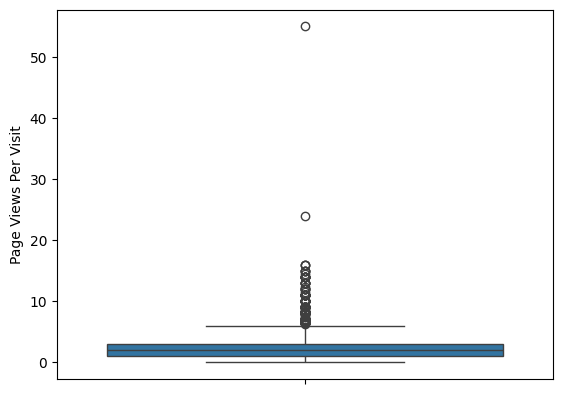

In [ ]:
sns.boxplot(df['Page Views Per Visit'])

In [ ]:
### Impute null using Median


df['Page Views Per Visit'] = df['Page Views Per Visit'].fillna(df['Page Views Per Visit'].median())
df['Page Views Per Visit'].isnull().sum()

np.int64(0)

In [ ]:
df['TotalVisits'] = df['TotalVisits'].fillna(df['TotalVisits'].median())
df['TotalVisits'].isnull().sum()

np.int64(0)

In [ ]:
### Train test split
df_train, df_test = train_test_split(df, train_size = 0.8, random_state = 100)
df_train.shape

(7392, 31)

In [ ]:
df_test.shape

(1848, 31)

In [ ]:
df.describe()

,Do Not Email,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,A free copy of Mastering The Interview,Lead Origin_Landing Page Submission,Lead Origin_Lead Add Form,Lead Origin_Lead Import,Lead Origin_Quick Add Form,...,Last Activity_Other,Last Activity_Page Visited on Website,Last Activity_SMS Sent,Last Notable Activity_Email Link Clicked,Last Notable Activity_Email Opened,Last Notable Activity_Modified,Last Notable Activity_Olark Chat Conversation,Last Notable Activity_Other,Last Notable Activity_Page Visited on Website,Last Notable Activity_SMS Sent
count,9240.000000,9240.000000,9240.000000,9240.000000,9240.000000,9240.000000,9240.000000,9240.000000,9240.000000,9240.000000,...,9240.000000,9240.000000,9240.000000,9240.000000,9240.000000,9240.000000,9240.000000,9240.000000,9240.000000,9240.000000
mean,0.079437,0.385390,3.438636,487.698268,2.357440,0.312554,0.528788,0.077706,0.005952,0.000108,...,0.045887,0.069264,0.297078,0.018723,0.305952,0.368723,0.019805,0.010823,0.034416,0.235065
std,0.270435,0.486714,4.819024,548.021466,2.145781,0.463559,0.499198,0.267722,0.076926,0.010403,...,0.209252,0.253916,0.456996,0.135552,0.460835,0.482485,0.139338,0.103472,0.182304,0.424062
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,1.000000,12.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,3.000000,248.000000,2.000000,0.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,1.000000,5.000000,936.000000,3.000000,1.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,251.000000,2272.000000,55.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df_train[['TotalVisits',	'Total Time Spent on Website',	'Page Views Per Visit']] = scaler.fit_transform(df_train[['TotalVisits',	'Total Time Spent on Website',	'Page Views Per Visit']])
df_train.describe()

,Do Not Email,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,A free copy of Mastering The Interview,Lead Origin_Landing Page Submission,Lead Origin_Lead Add Form,Lead Origin_Lead Import,Lead Origin_Quick Add Form,...,Last Activity_Other,Last Activity_Page Visited on Website,Last Activity_SMS Sent,Last Notable Activity_Email Link Clicked,Last Notable Activity_Email Opened,Last Notable Activity_Modified,Last Notable Activity_Olark Chat Conversation,Last Notable Activity_Other,Last Notable Activity_Page Visited on Website,Last Notable Activity_SMS Sent
count,7392.000000,7392.000000,7392.000000,7392.000000,7392.000000,7392.000000,7392.000000,7392.000000,7392.000000,7392.000000,...,7392.000000,7392.000000,7392.000000,7392.000000,7392.000000,7392.000000,7392.000000,7392.000000,7392.000000,7392.000000
mean,0.079140,0.382711,0.013854,0.212672,0.042952,0.311959,0.530032,0.079140,0.005411,0.000135,...,0.045319,0.070887,0.300054,0.019075,0.305601,0.366613,0.019075,0.010823,0.035038,0.237960
std,0.269975,0.486082,0.020450,0.240339,0.039535,0.463324,0.499131,0.269975,0.073367,0.011631,...,0.208018,0.256654,0.458312,0.136797,0.460693,0.481912,0.136797,0.103474,0.183888,0.425863
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.003984,0.005282,0.018182,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.011952,0.108275,0.036364,0.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,1.000000,0.019920,0.406690,0.054545,1.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
y_train = df_train.pop('Converted')
x_train = df_train

In [ ]:
## modelling

log = sm.GLM (y_train, sm.add_constant(x_train), family = sm.families.Binomial())
log.fit()

In [ ]:
print(log.fit().summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:              Converted   No. Observations:                 7392
Model:                            GLM   Df Residuals:                     7361
Model Family:                Binomial   Df Model:                           30
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3228.9
Date:                Mon, 03 Aug 2026   Deviance:                       6457.8
Time:                        15:47:41   Pearson chi2:                 7.52e+03
No. Iterations:                    19   Pseudo R-squ. (CS):             0.3669
Covariance Type:            nonrobust                                         
                                                    coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------

In [ ]:
logreg = LogisticRegression()

In [ ]:
#### RFE -> Recursive Feature Elimination

#Dimensionality Reduction
# PCA
# Lasso Reg
## RFE -> It chooses the most relevant non-collinear features for us to work with


from sklearn.feature_selection import RFE

rfe = RFE(estimator = logreg,n_features_to_select = 25)
rfe = rfe.fit(x_train, y_train)


In [ ]:
list(zip( x_train.columns, rfe.support_,rfe.ranking_))

[('Do Not Email', np.True_, np.int64(1)),
 ('TotalVisits', np.True_, np.int64(1)),
 ('Total Time Spent on Website', np.True_, np.int64(1)),
 ('Page Views Per Visit', np.True_, np.int64(1)),
 ('A free copy of Mastering The Interview', np.False_, np.int64(5)),
 ('Lead Origin_Landing Page Submission', np.False_, np.int64(3)),
 ('Lead Origin_Lead Add Form', np.True_, np.int64(1)),
 ('Lead Origin_Lead Import', np.True_, np.int64(1)),
 ('Lead Origin_Quick Add Form', np.True_, np.int64(1)),
 ('Lead Source_Google', np.True_, np.int64(1)),
 ('Lead Source_Olark Chat', np.True_, np.int64(1)),
 ('Lead Source_Organic Search', np.True_, np.int64(1)),
 ('Lead Source_Other', np.True_, np.int64(1)),
 ('Lead Source_Reference', np.True_, np.int64(1)),
 ('Lead Source_Referral Sites', np.False_, np.int64(6)),
 ('Lead Source_Welingak Website', np.True_, np.int64(1)),
 ('Last Activity_Email Bounced', np.False_, np.int64(4)),
 ('Last Activity_Email Link Clicked', np.True_, np.int64(1)),
 ('Last Activity_Email

In [ ]:
col = x_train.columns[rfe.support_]
col

Index(['Do Not Email', 'TotalVisits', 'Total Time Spent on Website',
       'Page Views Per Visit', 'Lead Origin_Lead Add Form',
       'Lead Origin_Lead Import', 'Lead Origin_Quick Add Form',
       'Lead Source_Google', 'Lead Source_Olark Chat',
       'Lead Source_Organic Search', 'Lead Source_Other',
       'Lead Source_Reference', 'Lead Source_Welingak Website',
       'Last Activity_Email Link Clicked', 'Last Activity_Email Opened',
       'Last Activity_Olark Chat Conversation', 'Last Activity_Other',
       'Last Activity_SMS Sent', 'Last Notable Activity_Email Link Clicked',
       'Last Notable Activity_Email Opened', 'Last Notable Activity_Modified',
       'Last Notable Activity_Olark Chat Conversation',
       'Last Notable Activity_Other',
       'Last Notable Activity_Page Visited on Website',
       'Last Notable Activity_SMS Sent'],
      dtype='object')

In [ ]:
x_train.columns[~rfe.support_]

Index(['A free copy of Mastering The Interview',
       'Lead Origin_Landing Page Submission', 'Lead Source_Referral Sites',
       'Last Activity_Email Bounced', 'Last Activity_Page Visited on Website'],
      dtype='object')

In [ ]:
### Fitting the model again

x_train_sm = sm.add_constant(x_train[col])
log2 = sm.GLM(y_train, x_train_sm, family = sm.families. Binomial())
res = log2.fit()
print(res.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:              Converted   No. Observations:                 7392
Model:                            GLM   Df Residuals:                     7366
Model Family:                Binomial   Df Model:                           25
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3230.4
Date:                Mon, 03 Aug 2026   Deviance:                       6460.8
Time:                        15:57:05   Pearson chi2:                 7.52e+03
No. Iterations:                    19   Pseudo R-squ. (CS):             0.3666
Covariance Type:            nonrobust                                         
                                                    coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------

In [ ]:
col = col.drop('Lead Origin_Quick Add Form')

In [ ]:
col

Index(['Do Not Email', 'TotalVisits', 'Total Time Spent on Website',
       'Page Views Per Visit', 'Lead Origin_Lead Add Form',
       'Lead Origin_Lead Import', 'Lead Source_Google',
       'Lead Source_Olark Chat', 'Lead Source_Organic Search',
       'Lead Source_Other', 'Lead Source_Reference',
       'Lead Source_Welingak Website', 'Last Activity_Email Link Clicked',
       'Last Activity_Email Opened', 'Last Activity_Olark Chat Conversation',
       'Last Activity_Other', 'Last Activity_SMS Sent',
       'Last Notable Activity_Email Link Clicked',
       'Last Notable Activity_Email Opened', 'Last Notable Activity_Modified',
       'Last Notable Activity_Olark Chat Conversation',
       'Last Notable Activity_Other',
       'Last Notable Activity_Page Visited on Website',
       'Last Notable Activity_SMS Sent'],
      dtype='object')

In [ ]:
### Fitting the model again

x_train_sm = sm.add_constant(x_train[col])
log3 = sm.GLM(y_train, x_train_sm, family = sm.families. Binomial())
res = log3.fit()
print(res.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:              Converted   No. Observations:                 7392
Model:                            GLM   Df Residuals:                     7367
Model Family:                Binomial   Df Model:                           24
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3231.1
Date:                Mon, 03 Aug 2026   Deviance:                       6462.1
Time:                        15:58:12   Pearson chi2:                 7.53e+03
No. Iterations:                     7   Pseudo R-squ. (CS):             0.3665
Covariance Type:            nonrobust                                         
                                                    coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------

In [ ]:
### vif


# Check for the VIF values of the feature variables.
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [ ]:
# Create a dataframe that will contain the names of all the feature variables and their respective VIFs
vif = pd.DataFrame()
vif['Features'] = x_train[col].columns
vif['VIF'] = [variance_inflation_factor(x_train[col].values, i) for i in range(x_train[col].shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
4,Lead Origin_Lead Add Form,36.95
10,Lead Source_Reference,28.88
18,Last Notable Activity_Email Opened,10.34
13,Last Activity_Email Opened,9.84
23,Last Notable Activity_SMS Sent,8.42
16,Last Activity_SMS Sent,7.87
11,Lead Source_Welingak Website,7.75
19,Last Notable Activity_Modified,5.43
3,Page Views Per Visit,4.15
9,Lead Source_Other,4.05


In [ ]:
col = col.drop('Lead Origin_Lead Add Form')

In [ ]:
### Fitting the model again

x_train_sm = sm.add_constant(x_train[col])
log4 = sm.GLM(y_train, x_train_sm, family = sm.families. Binomial())
res = log4.fit()
print(res.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:              Converted   No. Observations:                 7392
Model:                            GLM   Df Residuals:                     7368
Model Family:                Binomial   Df Model:                           23
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3242.3
Date:                Mon, 03 Aug 2026   Deviance:                       6484.6
Time:                        16:00:07   Pearson chi2:                 7.53e+03
No. Iterations:                     7   Pseudo R-squ. (CS):             0.3646
Covariance Type:            nonrobust                                         
                                                    coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------

In [ ]:
# Create a dataframe that will contain the names of all the feature variables and their respective VIFs
vif = pd.DataFrame()
vif['Features'] = x_train[col].columns
vif['VIF'] = [variance_inflation_factor(x_train[col].values, i) for i in range(x_train[col].shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
17,Last Notable Activity_Email Opened,10.34
12,Last Activity_Email Opened,9.83
22,Last Notable Activity_SMS Sent,8.42
15,Last Activity_SMS Sent,7.87
18,Last Notable Activity_Modified,5.43
3,Page Views Per Visit,4.14
11,Last Activity_Email Link Clicked,3.23
16,Last Notable Activity_Email Link Clicked,3.17
13,Last Activity_Olark Chat Conversation,2.64
6,Lead Source_Olark Chat,2.62


In [ ]:
col = col.drop('Last Notable Activity_SMS Sent')

In [ ]:
### Fitting the model again

x_train_sm = sm.add_constant(x_train[col])
log5 = sm.GLM(y_train, x_train_sm, family = sm.families. Binomial())
res = log5.fit()
print(res.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:              Converted   No. Observations:                 7392
Model:                            GLM   Df Residuals:                     7369
Model Family:                Binomial   Df Model:                           22
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3242.3
Date:                Mon, 03 Aug 2026   Deviance:                       6484.7
Time:                        16:01:39   Pearson chi2:                 7.53e+03
No. Iterations:                     7   Pseudo R-squ. (CS):             0.3646
Covariance Type:            nonrobust                                         
                                                    coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------

In [ ]:
# Create a dataframe that will contain the names of all the feature variables and their respective VIFs
vif = pd.DataFrame()
vif['Features'] = x_train[col].columns
vif['VIF'] = [variance_inflation_factor(x_train[col].values, i) for i in range(x_train[col].shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
12,Last Activity_Email Opened,8.93
17,Last Notable Activity_Email Opened,8.44
3,Page Views Per Visit,3.99
11,Last Activity_Email Link Clicked,3.16
18,Last Notable Activity_Modified,3.14
16,Last Notable Activity_Email Link Clicked,3.06
15,Last Activity_SMS Sent,2.57
6,Lead Source_Olark Chat,2.45
13,Last Activity_Olark Chat Conversation,2.40
2,Total Time Spent on Website,2.14


In [ ]:
y_train_pred = res.predict(x_train_sm)
y_train_pred.head()

,0
7263,0.234040
6468,0.364364
7833,0.336892
4461,0.934058
8453,0.066373


In [ ]:
y_train.shape

(7392,)

In [ ]:
y_train_pred.shape

(7392,)

In [ ]:
df2 = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Lead Scoring Assignment - Logistic Regression/Leads.csv')
df2.head()

,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,...,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737,API,Olark Chat,No,No,0,0.0,0,0.0,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Modified
1,2a272436-5132-4136-86fa-dcc88c88f482,660728,API,Organic Search,No,No,0,5.0,674,2.5,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Email Opened
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,660727,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,2.0,...,No,Potential Lead,Mumbai,02.Medium,01.High,14.0,20.0,No,Yes,Email Opened
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,660719,Landing Page Submission,Direct Traffic,No,No,0,1.0,305,1.0,...,No,Select,Mumbai,02.Medium,01.High,13.0,17.0,No,No,Modified
4,3256f628-e534-4826-9d63-4a8b88782852,660681,Landing Page Submission,Google,No,No,1,2.0,1428,1.0,...,No,Select,Mumbai,02.Medium,01.High,15.0,18.0,No,No,Modified


In [ ]:
df2 = df2[['Prospect ID','Lead Number']]

In [ ]:
df2.head()

,Prospect ID,Lead Number
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737
1,2a272436-5132-4136-86fa-dcc88c88f482,660728
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,660727
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,660719
4,3256f628-e534-4826-9d63-4a8b88782852,660681


In [ ]:
y_train_final = pd.concat([y_train_pred, y_train], axis = 1)
y_train_final.head()

,0,Converted
7263,0.234040,1
6468,0.364364,0
7833,0.336892,1
4461,0.934058,0
8453,0.066373,0


In [ ]:
y_train_final = y_train_final.rename(columns = {y_train_final.columns[0]:'predicted_score'})


In [ ]:
y_train_final.head()

,predicted_score,Converted
7263,0.234040,1
6468,0.364364,0
7833,0.336892,1
4461,0.934058,0
8453,0.066373,0


In [ ]:
y_train_final['predicted'] = y_train_final['predicted_score'].map(lambda x: 1 if x > 0.5 else 0)

y_train_final.head()

,predicted_score,Converted,predicted
7263,0.234040,1,0
6468,0.364364,0,0
7833,0.336892,1,0
4461,0.934058,0,1
8453,0.066373,0,0


In [ ]:
#### Evaluate


from sklearn import metrics



In [ ]:
confusion = metrics.confusion_matrix (y_train_final.Converted, y_train_final.predicted)
print(confusion)

[[3999  564]
 [ 903 1926]]


In [ ]:
print(metrics.accuracy_score(y_train_final.Converted, y_train_final.predicted))

0.8015422077922078


In [ ]:
TP = confusion[1,1]
TN = confusion[0,0]
FP = confusion[0,1]
FN = confusion[1,0]

In [ ]:
#### Senstivity / Recall

TP/ float (TP + FP)

np.float64(0.7734939759036145)

In [ ]:
## Specificity

TN/float (TN+FP)

np.float64(0.8763971071663379)

In [ ]:
### False positive Rate

FP/float (TN+FP)

np.float64(0.12360289283366206)

In [ ]:
### ROC


def draw_roc( actual, probs ):
    fpr, tpr, thresholds = metrics.roc_curve( actual, probs,
                                              drop_intermediate = False )
    auc_score = metrics.roc_auc_score( actual, probs )
    plt.figure(figsize=(5, 5))
    plt.plot( fpr, tpr, label='ROC curve (area = %0.2f)' % auc_score )
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate or [1 - True Negative Rate]')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver operating characteristic example')
    plt.legend(loc="lower right")
    plt.show()

    return None

In [ ]:
fpr, tpr, thresholds = metrics.roc_curve( y_train_final.Converted, y_train_final.predicted, drop_intermediate= False)


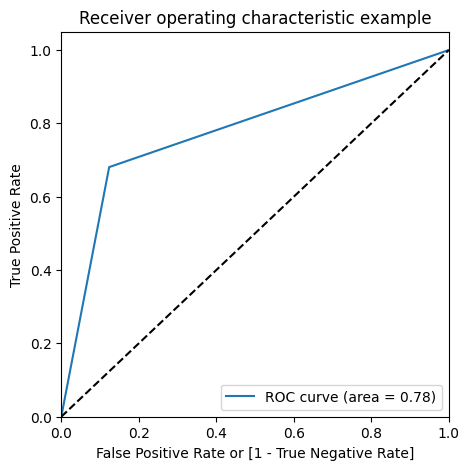

In [ ]:
draw_roc(y_train_final.Converted, y_train_final.predicted)

In [ ]:
### Finding most optimal values of threshold

numbers = [float(x)/10 for x in range(10)]

for i in numbers:
  y_train_final[i] = y_train_final['predicted_score'].map(lambda x: 1 if x > i else 0)

y_train_final.head()

,predicted_score,Converted,predicted,0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9
7263,0.234040,1,0,1,1,1,0,0,0,0,0,0,0
6468,0.364364,0,0,1,1,1,1,0,0,0,0,0,0
7833,0.336892,1,0,1,1,1,1,0,0,0,0,0,0
4461,0.934058,0,1,1,1,1,1,1,1,1,1,1,1
8453,0.066373,0,0,1,0,0,0,0,0,0,0,0,0


In [ ]:
# Now let's calculate accuracy sensitivity and specificity for various probability cutoffs.
cutoff_df = pd.DataFrame( columns = ['prob','accuracy','sensi','speci'])
from sklearn.metrics import confusion_matrix

# TP = confusion[1,1] # true positive
# TN = confusion[0,0] # true negatives
# FP = confusion[0,1] # false positives
# FN = confusion[1,0] # false negatives

num = [0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
for i in num:
    cm1 = metrics.confusion_matrix(y_train_final.Converted, y_train_final[i] )
    total1=sum(sum(cm1))
    accuracy = (cm1[0,0]+cm1[1,1])/total1

    speci = cm1[0,0]/(cm1[0,0]+cm1[0,1])
    sensi = cm1[1,1]/(cm1[1,0]+cm1[1,1])
    cutoff_df.loc[i] =[ i ,accuracy,sensi,speci]
print(cutoff_df)

     prob  accuracy     sensi     speci
0.0   0.0  0.382711  1.000000  0.000000
0.1   0.1  0.578734  0.971368  0.335306
0.2   0.2  0.729031  0.913397  0.614727
0.3   0.3  0.796537  0.830329  0.775586
0.4   0.4  0.801272  0.761400  0.825992
0.5   0.5  0.801542  0.680806  0.876397
0.6   0.6  0.793155  0.608342  0.907736
0.7   0.7  0.764340  0.473666  0.944554
0.8   0.8  0.736878  0.369035  0.964935
0.9   0.9  0.684524  0.196182  0.987289


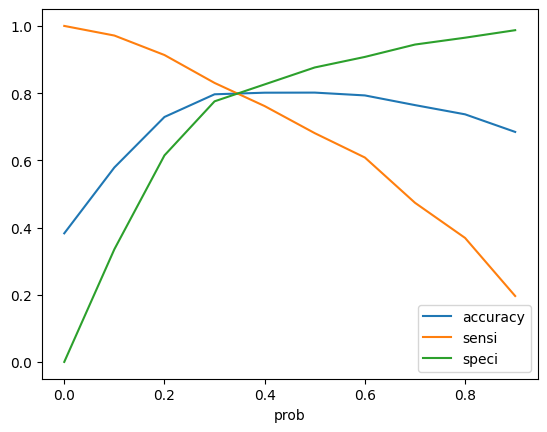

In [ ]:
cutoff_df.plot.line(x = 'prob',y = ['accuracy','sensi','speci'])
plt.show()

In [ ]:
y_train_final['final prediction'] = y_train_final['predicted_score'].map(lambda x: 1 if x > 0.37 else 0)

In [ ]:
y_train_final.head()

,predicted_score,Converted,predicted,0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,final prediction
7263,0.234040,1,0,1,1,1,0,0,0,0,0,0,0,0
6468,0.364364,0,0,1,1,1,1,0,0,0,0,0,0,0
7833,0.336892,1,0,1,1,1,1,0,0,0,0,0,0,0
4461,0.934058,0,1,1,1,1,1,1,1,1,1,1,1,1
8453,0.066373,0,0,1,0,0,0,0,0,0,0,0,0,0


In [ ]:
confusion2 = metrics.confusion_matrix(y_train_final['Converted'], y_train_final['final prediction'] )
confusion2

array([[3697,  866],
       [ 601, 2228]])

In [ ]:
TP = confusion2[1,1]
TN = confusion2[0,0]
FP = confusion2[0,1]
FN = confusion2[1,0]

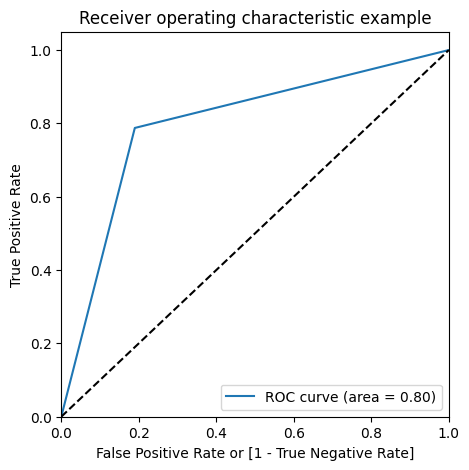

In [ ]:
draw_roc(y_train_final['Converted'], y_train_final['final prediction'] )

In [ ]:
from sklearn.metrics import precision_recall_curve

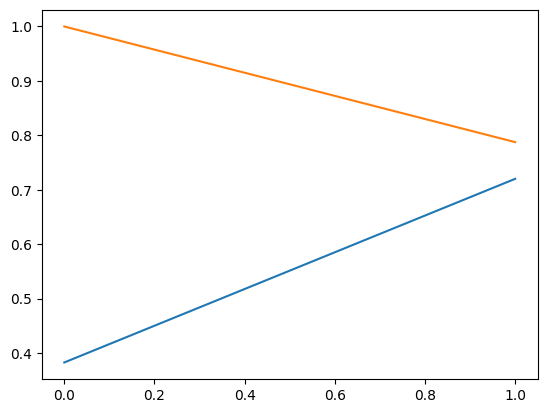

In [ ]:
p, r, thresholds = precision_recall_curve(y_train_final['Converted'], y_train_final['final prediction'])

plt.plot(thresholds, p[:-1]
         )
plt.plot(thresholds, r[:-1])
plt.show()

In [ ]:
p = TP/float(TP + FP
             )

r = TP/float(TP+FN)

In [ ]:
f1_score = (2 * p * r )/(p+r)

In [ ]:
f1_score

np.float64(0.752321458720243)

In [ ]:
### test on test
y_test = df_test.pop('Converted')
x_test = df_test

In [ ]:
x_test.describe()

,Do Not Email,TotalVisits,Total Time Spent on Website,Page Views Per Visit,A free copy of Mastering The Interview,Lead Origin_Landing Page Submission,Lead Origin_Lead Add Form,Lead Origin_Lead Import,Lead Origin_Quick Add Form,Lead Source_Google,...,Last Activity_Other,Last Activity_Page Visited on Website,Last Activity_SMS Sent,Last Notable Activity_Email Link Clicked,Last Notable Activity_Email Opened,Last Notable Activity_Modified,Last Notable Activity_Olark Chat Conversation,Last Notable Activity_Other,Last Notable Activity_Page Visited on Website,Last Notable Activity_SMS Sent
count,1848.000000,1848.000000,1848.000000,1848.000000,1848.000000,1848.000000,1848.000000,1848.000000,1848.0,1848.000000,...,1848.000000,1848.000000,1848.000000,1848.000000,1848.000000,1848.000000,1848.000000,1848.000000,1848.000000,1848.000000
mean,0.080628,3.283550,505.727814,2.337863,0.314935,0.523810,0.071970,0.008117,0.0,0.297619,...,0.048160,0.062771,0.285173,0.017316,0.307359,0.377165,0.022727,0.010823,0.031926,0.223485
std,0.272336,3.272287,555.615821,2.027598,0.464616,0.499568,0.258508,0.089752,0.0,0.457335,...,0.214163,0.242615,0.451619,0.130481,0.461524,0.484808,0.149073,0.103495,0.175852,0.416693
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,8.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,3.000000,262.500000,2.000000,0.000000,1.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,5.000000,965.250000,3.330000,1.000000,1.000000,0.000000,0.000000,0.0,1.000000,...,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,42.000000,2207.000000,16.000000,1.000000,1.000000,1.000000,1.000000,0.0,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
x_test[['TotalVisits','Total Time Spent on Website','Page Views Per Visit']] = scaler.transform(x_test[['TotalVisits','Total Time Spent on Website','Page Views Per Visit']])
x_test.head()

,Do Not Email,TotalVisits,Total Time Spent on Website,Page Views Per Visit,A free copy of Mastering The Interview,Lead Origin_Landing Page Submission,Lead Origin_Lead Add Form,Lead Origin_Lead Import,Lead Origin_Quick Add Form,Lead Source_Google,...,Last Activity_Other,Last Activity_Page Visited on Website,Last Activity_SMS Sent,Last Notable Activity_Email Link Clicked,Last Notable Activity_Email Opened,Last Notable Activity_Modified,Last Notable Activity_Olark Chat Conversation,Last Notable Activity_Other,Last Notable Activity_Page Visited on Website,Last Notable Activity_SMS Sent
4269,0,0.031873,0.444982,0.145455,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,1
2376,0,0.000000,0.000000,0.000000,0,0,1,0,0,0,...,0,0,1,0,0,0,0,0,0,1
7766,0,0.019920,0.025968,0.090909,0,0,0,0,0,1,...,1,0,0,0,0,0,0,1,0,0
9199,0,0.000000,0.000000,0.000000,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4359,0,0.000000,0.000000,0.000000,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,0


In [ ]:
x_test = x_test[col]

In [ ]:
x_test_sm = sm.add_constant(x_test)

In [ ]:
y_test_pred = res.predict(x_test_sm)
y_test_pred.head()

,0
4269,0.732945
2376,0.967076
7766,0.396036
9199,0.066373
4359,0.879974


In [ ]:
y_test_pred.head()

,0
4269,0.732945
2376,0.967076
7766,0.396036
9199,0.066373
4359,0.879974


In [ ]:
y_test_pred = y_test_pred.rename('predicted_score')

In [ ]:
y_test_pred.head()

,predicted_score
4269,0.732945
2376,0.967076
7766,0.396036
9199,0.066373
4359,0.879974


AttributeError: 'Series' object has no attribute 'predicted_score'

In [ ]:
y_test_pred = y_test_pred.map(lambda x : 1 if x > 0.37 else 0 )
y_test_pred.head()

,predicted_score
4269,1
2376,1
7766,1
9199,0
4359,1


In [ ]:
y_test_pred

,predicted_score
4269,1
2376,1
7766,1
9199,0
4359,1
...,...
4711,0
4874,0
935,1
2849,0


In [ ]:
y_test

,Converted
4269,1
2376,1
7766,1
9199,0
4359,1
...,...
4711,0
4874,0
935,1
2849,0


In [ ]:
y_test_final = pd.concat([y_test, y_test_pred], axis = 1 )

In [ ]:
y_test_final

,Converted,predicted_score
4269,1,1
2376,1,1
7766,1,1
9199,0,0
4359,1,1
...,...,...
4711,0,0
4874,0,0
935,1,1
2849,0,0


In [ ]:
confusion3 = metrics.confusion_matrix(y_test_final.Converted, y_test_final.predicted_score )
confusion3

array([[899, 217],
       [153, 579]])

In [ ]:
TP = confusion3[1,1] # true positive
TN = confusion3[0,0] # true negatives
FP = confusion3[0,1] # false positives
FN = confusion3[1,0] # false negatives

In [ ]:
p = TP/float(TP + FP
             )

r = TP/float(TP+FN)

In [ ]:
f1_score =( 2 * p * r )/(r+p)


In [ ]:
f1_score

np.float64(0.7578534031413613)